# Perturbation recovery comparison

This notebook compares intervention-enabled recovery for `csd_n10_k3_umi_paired` and `20260805_174708`. Both runs are restricted to `missing_data_rate == 0` and `missing_edge_rate == 0`, and results are grouped by sample size.

The reported recovery counts are for edges in the shared baseline non-identifiability diagnosis. A row is recovered when it is complete and has `status == identifiable`. Coefficient error is calculated only for recovered rows with finite estimated and ground-truth coefficients.

In [38]:
from pathlib import Path
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve()
while not (REPO / 'src' / 'nocap').exists() and REPO != REPO.parent:
    REPO = REPO.parent
BASE = REPO / 'notebooks' / 'Ecoli_Analysis_Notebooks'
RUNS = {
    'csd_n10_k3_umi_paired': BASE / 'estimation' / 'csd_n10_k3_umi_paired' / 'csv',
    '20260805_174708': BASE / 'estimation' / '20260805_174708' / 'csv',
}
DIAGNOSIS_PATH = BASE / 'csd_nonident_diagnosis.csv'
OUT_DIR = BASE / 'estimation' / 'perturbation'
VIZ_DIR = OUT_DIR / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)
assert DIAGNOSIS_PATH.exists(), f'Missing diagnosis file: {DIAGNOSIS_PATH}'
print({name: len(list(path.glob('*.csv'))) for name, path in RUNS.items()})

{'csd_n10_k3_umi_paired': 240, '20260805_174708': 336}


In [39]:
diagnosis = pd.read_csv(DIAGNOSIS_PATH).drop_duplicates(['cause', 'effect']).copy()
diagnosis['edge'] = diagnosis['cause'].astype('string') + '->' + diagnosis['effect'].astype('string')

frames = []
for run_name, input_dir in RUNS.items():
    paths = sorted(input_dir.glob('*.csv'))
    assert paths, f'No CSV files found in {input_dir}'
    for path in paths:
        try:
            frame = pd.read_csv(path)
            frame['run'] = run_name
            frame['csv_file'] = path.name
            frames.append(frame)
        except pd.errors.EmptyDataError:
            print(f"{path} is empty, skipping file")
            continue
results = pd.concat(frames, ignore_index=True)
required = {
    'cause', 'effect', 'status', 'run_status', 'n_samples',
    'missing_edge_rate', 'missing_data_rate', 'missing_data_mechanism',
    'estimated_path_coefficient', 'ground_truth_beta', 'intervention_id',
    'scm_seed', 'data_seed',
}
missing = sorted(required - set(results.columns))
assert not missing, f'Missing required columns: {missing}'
for col in ['n_samples', 'missing_edge_rate', 'missing_data_rate', 'estimated_path_coefficient', 'ground_truth_beta']:
    results[col] = pd.to_numeric(results[col], errors='coerce')
results['status'] = results['status'].astype('string').str.strip().str.lower()
results['run_status'] = results['run_status'].astype('string').str.strip().str.lower()
results['edge'] = results['cause'].astype('string') + '->' + results['effect'].astype('string')
results['complete'] = results['run_status'].isin(['', 'complete', 'completed'])

comparison = results.merge(
    diagnosis[['cause', 'effect', 'edge', 'nonident_cause']],
    on=['cause', 'effect', 'edge'], how='inner', validate='many_to_one',
)
comparison = comparison[
    comparison['missing_data_rate'].eq(0) & comparison['missing_edge_rate'].eq(0)
].copy()
comparison['recovered'] = comparison['complete'] & comparison['status'].eq('identifiable')
comparison['coefficient_error'] = comparison['estimated_path_coefficient'] - comparison['ground_truth_beta']
comparison['abs_error'] = comparison['coefficient_error'].abs()
comparison['sq_error'] = comparison['coefficient_error'] ** 2
numeric_recovery = comparison['recovered'] & comparison['coefficient_error'].notna() & np.isfinite(comparison['coefficient_error'])
comparison['numeric_recovery'] = numeric_recovery
print(f'Baseline non-identifiable edges: {len(diagnosis):,}')
print(f'Matched zero-missingness rows: {len(comparison):,}')
display(comparison.groupby(['run', 'n_samples'], dropna=False).size().rename('rows').reset_index())

/Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Notebooks/estimation/20260805_174708/csv/csd-20260805_174708_paired_hierarchical_0_0_9fcbe7390717f9dc_observational.csv is empty, skipping file
/Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Notebooks/estimation/20260805_174708/csv/csd-20260805_174708_paired_hierarchical_0_0_a27a5fca1f34e102_observational.csv is empty, skipping file
/Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Notebooks/estimation/20260805_174708/csv/csd-20260805_174708_paired_hierarchical_0_0_a89a61252272c3d0_observational.csv is empty, skipping file
/Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Note

,run,n_samples,rows
0,csd_n10_k3_umi_paired,100,266316
1,csd_n10_k3_umi_paired,1000,266316
2,csd_n10_k3_umi_paired,10000,226876


## Recovery across sample-size groups

`baseline_edges` is the number of diagnosed non-identifiable edges represented in a sample-size cell. `recovered_edges` counts unique edges with at least one recovered result; `recovery_rate` is their ratio.

In [40]:
group_cols = ['run', 'n_samples']
recovery_summary = (
    comparison.groupby(group_cols, dropna=False)
    .agg(
        baseline_edges=('edge', 'nunique'),
        result_rows=('edge', 'size'),
        recovered_rows=('recovered', 'sum'),
    )
    .reset_index()
)
# Count unique recovered edges explicitly to avoid counting repeated intervention rows.
unique_recovered = comparison.loc[comparison['recovered']].groupby(group_cols, dropna=False)['edge'].nunique()
recovery_keys = pd.MultiIndex.from_frame(recovery_summary[group_cols])
recovery_summary['recovered_edges'] = unique_recovered.reindex(recovery_keys, fill_value=0).to_numpy(dtype=int)
recovery_summary['recovery_rate'] = recovery_summary['recovered_edges'] / recovery_summary['baseline_edges']
recovery_summary = recovery_summary.sort_values(group_cols)
recovery_summary.to_csv(OUT_DIR / 'perturbation_recovery_by_sample_size.csv', index=False)
display(recovery_summary)

,run,n_samples,baseline_edges,result_rows,recovered_rows,recovered_edges,recovery_rate
0,csd_n10_k3_umi_paired,100,6676,266316,244764,6320,0.946675
1,csd_n10_k3_umi_paired,1000,6676,266316,244764,6320,0.946675
2,csd_n10_k3_umi_paired,10000,6676,226876,208849,6320,0.946675


In [41]:
cause_summary = (
    comparison.groupby(['run', 'n_samples', 'nonident_cause'], dropna=False)
    .agg(
        baseline_edges=('edge', 'nunique'),
        recovered_rows=('recovered', 'sum'),
    ).reset_index()
)
cause_group_cols = ['run', 'n_samples', 'nonident_cause']
cause_unique_recovered = comparison.loc[comparison['recovered']].groupby(cause_group_cols, dropna=False)['edge'].nunique()
cause_keys = pd.MultiIndex.from_frame(cause_summary[cause_group_cols])
cause_summary['recovered_edges'] = cause_unique_recovered.reindex(cause_keys, fill_value=0).to_numpy(dtype=int)
cause_summary['recovery_rate'] = cause_summary['recovered_edges'] / cause_summary['baseline_edges']
cause_summary['recovered_edge_share'] = (
    cause_summary['recovered_edges'] / cause_summary.groupby(['run', 'n_samples'])['recovered_edges'].transform('sum').replace(0, np.nan)
)
cause_summary = cause_summary.sort_values(['run', 'n_samples', 'nonident_cause'])
cause_summary.to_csv(OUT_DIR / 'perturbation_recovery_by_nonident_cause.csv', index=False)
display(cause_summary)

,run,n_samples,nonident_cause,baseline_edges,recovered_rows,recovered_edges,recovery_rate,recovered_edge_share
0,csd_n10_k3_umi_paired,100,cross_scc_blocked,6157,243804,6124,0.994640,0.968987
1,csd_n10_k3_umi_paired,100,same_scc_long,247,732,151,0.611336,0.023892
2,csd_n10_k3_umi_paired,100,scc_edge_dissolved,28,140,23,0.821429,0.003639
3,csd_n10_k3_umi_paired,100,self_loop,174,0,0,0.000000,0.000000
4,csd_n10_k3_umi_paired,100,two_cycle,70,88,22,0.314286,0.003481
5,csd_n10_k3_umi_paired,1000,cross_scc_blocked,6157,243804,6124,0.994640,0.968987
6,csd_n10_k3_umi_paired,1000,same_scc_long,247,732,151,0.611336,0.023892
7,csd_n10_k3_umi_paired,1000,scc_edge_dissolved,28,140,23,0.821429,0.003639
8,csd_n10_k3_umi_paired,1000,self_loop,174,0,0,0.000000,0.000000
9,csd_n10_k3_umi_paired,1000,two_cycle,70,88,22,0.314286,0.003481


## Coefficient recovery error

Error metrics are conditioned on recovered edges and are calculated over result rows, preserving replicate/intervention variation.

In [42]:
error_summary = (
    comparison[comparison['numeric_recovery']]
    .groupby(['run', 'n_samples'], dropna=False)
    .agg(
        recovered_rows=('edge', 'size'),
        recovered_edges=('edge', 'nunique'),
        MAE=('abs_error', 'mean'),
        RMSE=('sq_error', lambda x: float(np.sqrt(np.mean(x)))),
        bias=('coefficient_error', 'mean'),
        median_abs_error=('abs_error', 'median'),
    ).reset_index()
)
error_summary.to_csv(OUT_DIR / 'perturbation_coefficient_error_by_sample_size.csv', index=False)
display(error_summary)

,run,n_samples,recovered_rows,recovered_edges,MAE,RMSE,bias,median_abs_error
0,csd_n10_k3_umi_paired,100,244764,6320,0.215221,0.289429,-0.000226,0.163961
1,csd_n10_k3_umi_paired,1000,244764,6320,0.036911,0.050389,-0.000027,0.028997
2,csd_n10_k3_umi_paired,10000,208849,6320,0.012454,0.024011,-0.000007,0.008925


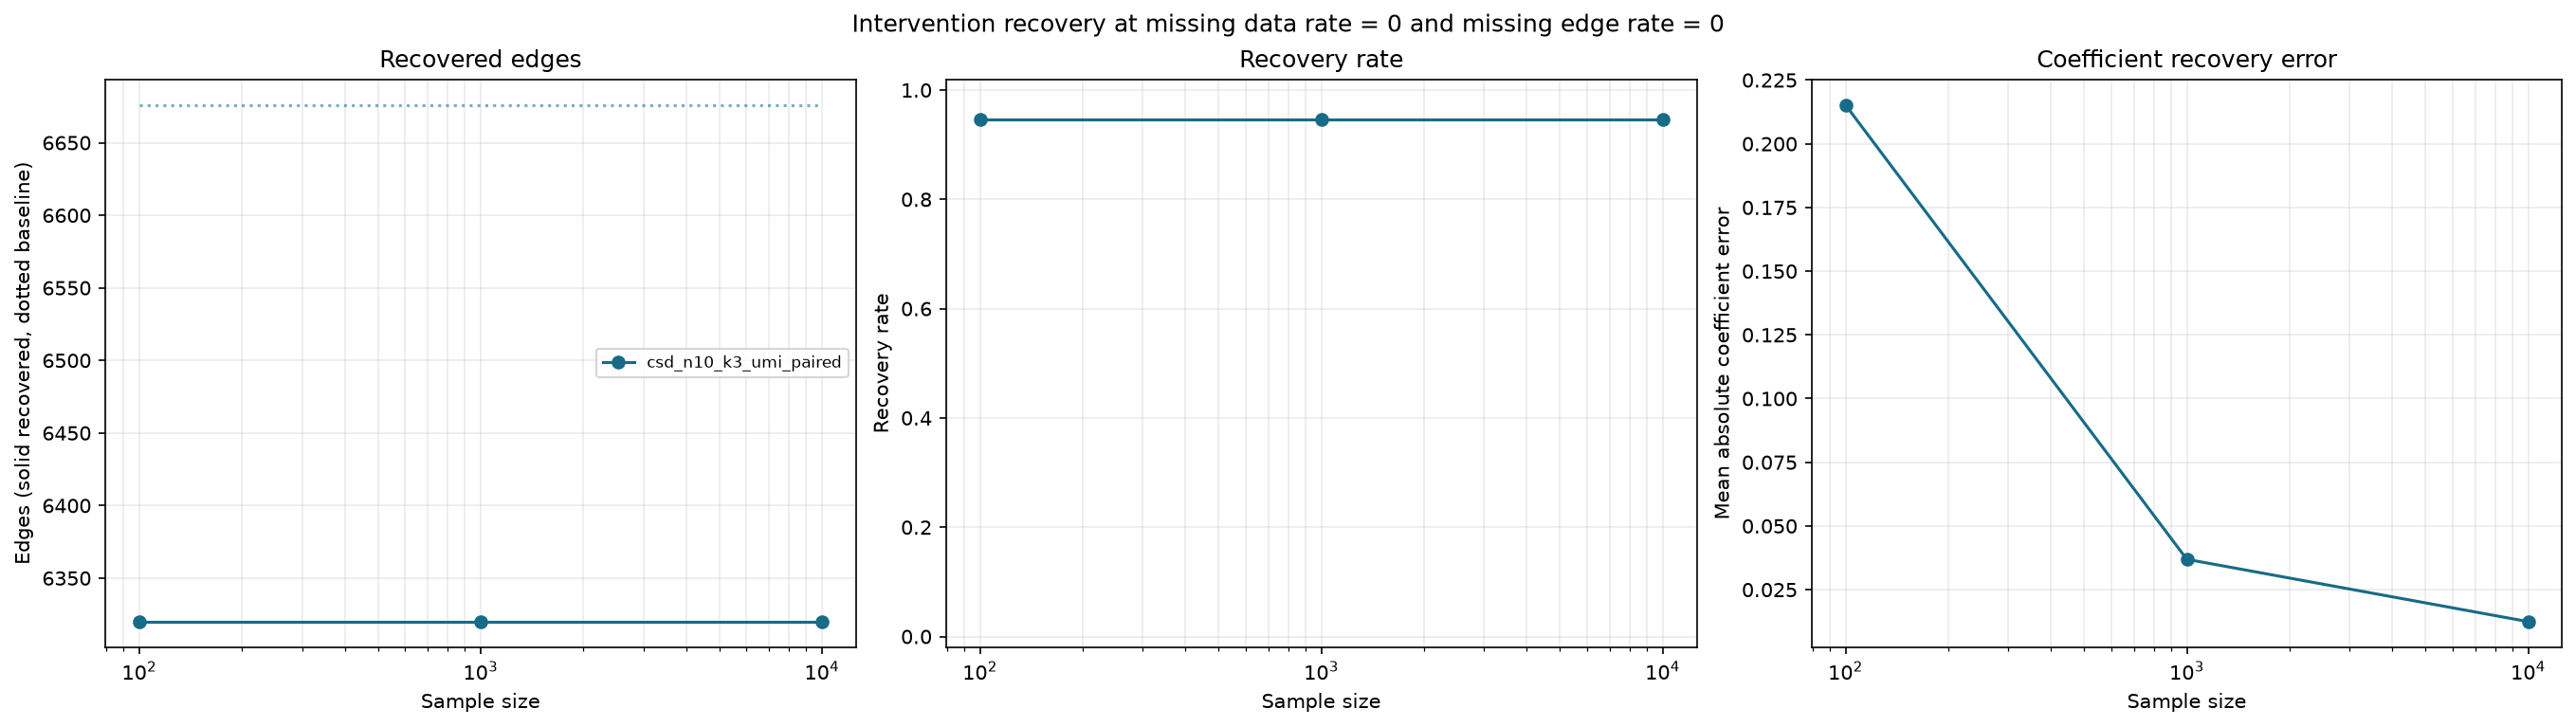

Saved: /Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Notebooks/estimation/perturbation/visualizations/perturbation_comparison_by_sample_size.png


In [43]:
# Plot the three requested comparisons with one panel per metric.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
colors = {'csd_n10_k3_umi_paired': '#176b87', '20260805_174708': '#d97706'}
labels = {'csd_n10_k3_umi_paired': 'csd_n10_k3_umi_paired', '20260805_174708': '20260805_174708'}
for run, part in recovery_summary.groupby('run'):
    part = part.sort_values('n_samples')
    axes[0].plot(part['n_samples'], part['recovered_edges'], marker='o', label=labels[run], color=colors[run])
    axes[0].plot(part['n_samples'], part['baseline_edges'], linestyle=':', color=colors[run], alpha=.55)
    axes[1].plot(part['n_samples'], part['recovery_rate'], marker='o', label=labels[run], color=colors[run])
for run, part in error_summary.groupby('run'):
    part = part.sort_values('n_samples')
    axes[2].plot(part['n_samples'], part['MAE'], marker='o', label=labels[run], color=colors[run])
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel('Sample size')
    ax.grid(True, which='both', alpha=.25)
axes[0].set_ylabel('Edges (solid recovered, dotted baseline)')
axes[0].set_title('Recovered edges')
axes[1].set_ylabel('Recovery rate')
axes[1].set_ylim(-.02, 1.02)
axes[1].set_title('Recovery rate')
axes[2].set_ylabel('Mean absolute coefficient error')
axes[2].set_title('Coefficient recovery error')
axes[0].legend(fontsize=8)
fig.suptitle('Intervention recovery at missing data rate = 0 and missing edge rate = 0')
plot_path = VIZ_DIR / 'perturbation_comparison_by_sample_size.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(str(plot_path)))
print(f'Saved: {plot_path}')

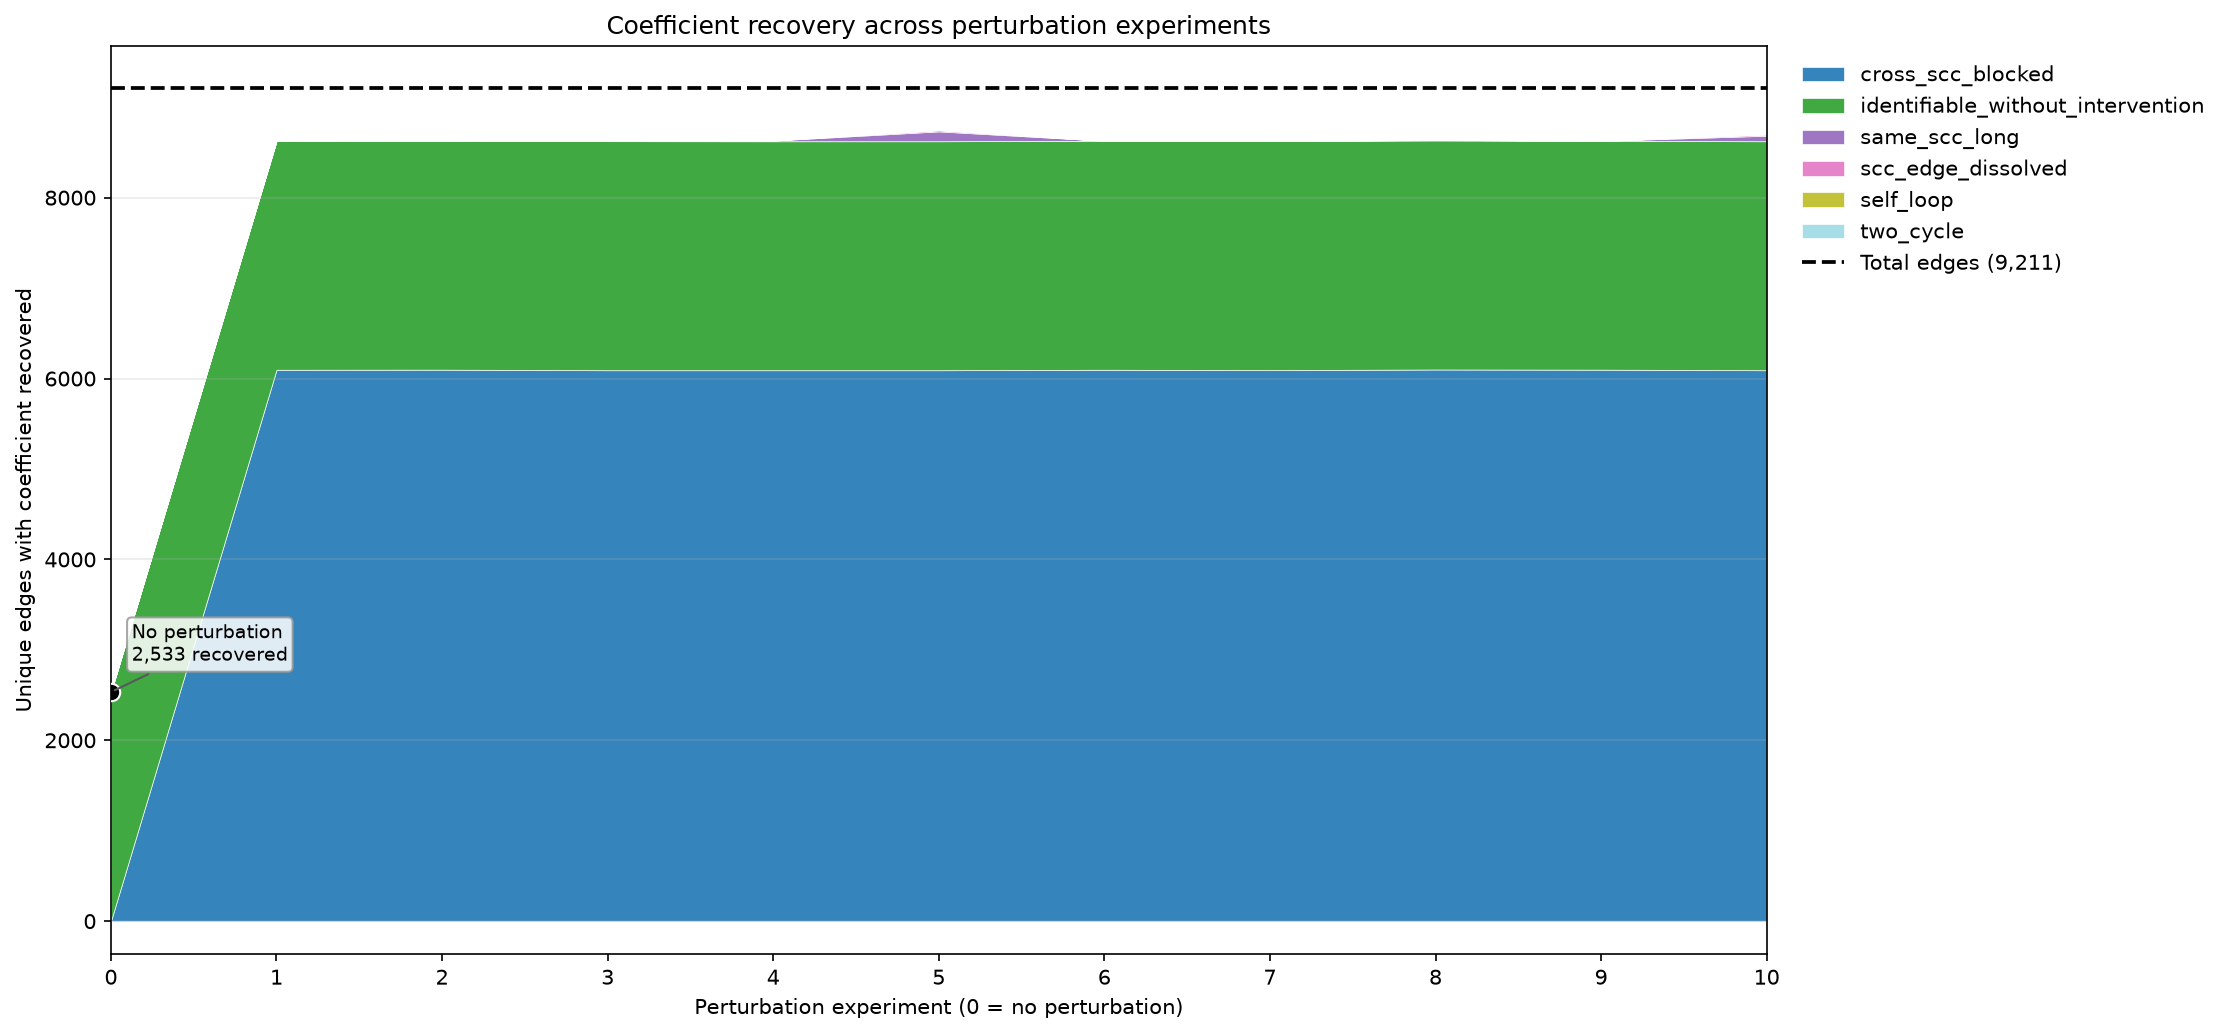

Total edges: 9,211
No-perturbation recovered edges: 2,533
Perturbation experiments: 10
Saved: /Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Notebooks/estimation/perturbation/visualizations/perturbation_recovery_area_by_experiment.png


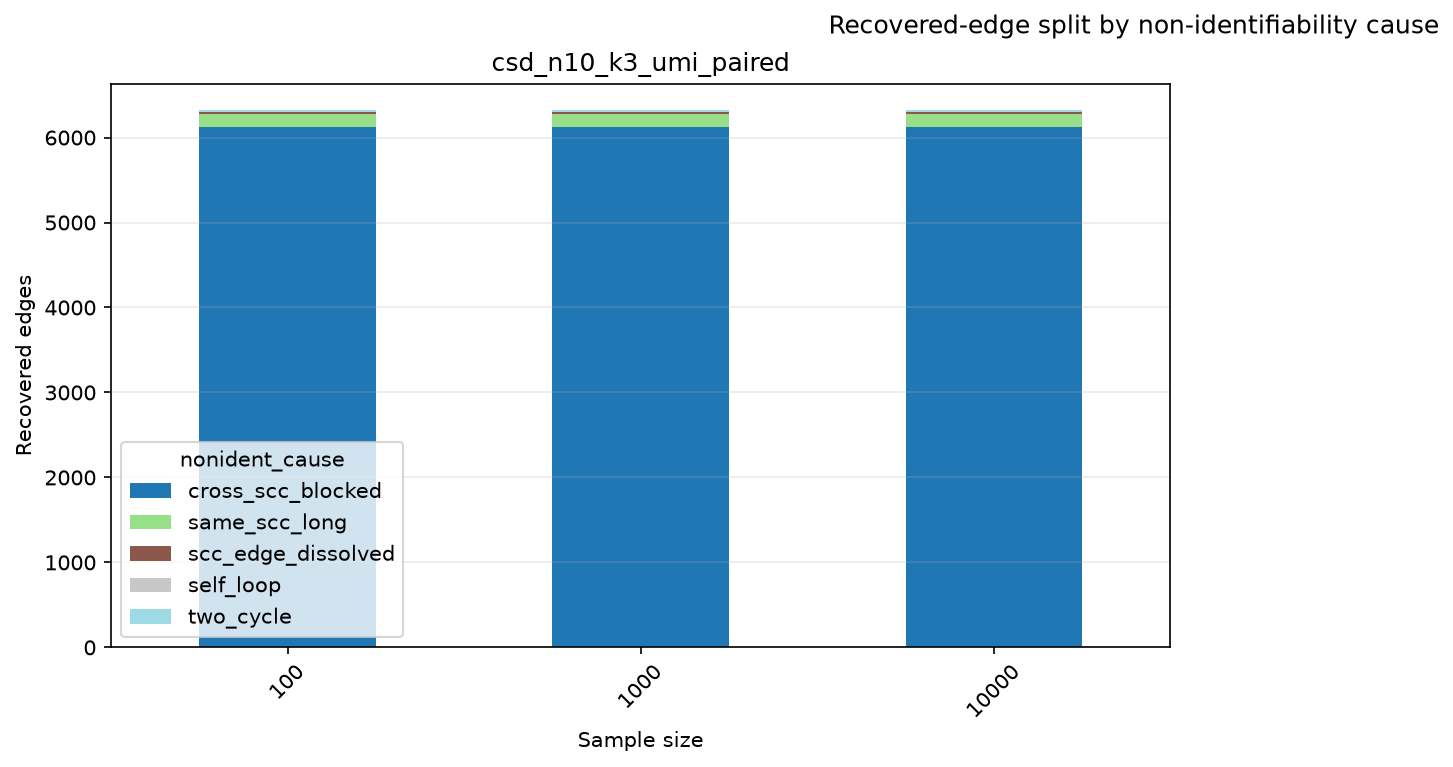

Saved: /Users/colin.pannikkat/projects/nocap.worktrees/32-parameter-estimation-via-single-door-criterion-for-cyclic-graphs/notebooks/Ecoli_Analysis_Notebooks/estimation/perturbation/visualizations/perturbation_recovery_nonident_cause_split.png


In [44]:
# Area plot: total coefficient-recovered edges by experiment.
# The observational run is experiment 0 and includes edges identifiable
# without intervention as well as edges recovered from the diagnosis.
total_edge_count = results['edge'].nunique()
perturbation_run = 'csd_n10_k3_umi_paired'
observational_run = '20260805_174708'
intervention_cols = ['intervention_id', 'intervention_set_index', 'intervention_genes', 'intervention_semantics']
for col in intervention_cols:
    comparison[col] = comparison[col].fillna('').astype('string')

area_results = results[results['missing_data_rate'].eq(0) & results['missing_edge_rate'].eq(0)].copy()
area_results = area_results.merge(diagnosis[['cause', 'effect', 'edge', 'nonident_cause']], on=['cause', 'effect', 'edge'], how='left')
area_results['nonident_cause'] = area_results['nonident_cause'].fillna('identifiable_without_intervention')
area_results['coefficient_recovered'] = (area_results['complete'] & area_results['status'].eq('identifiable') & area_results['estimated_path_coefficient'].notna() & area_results['ground_truth_beta'].notna())
observational_recovered = area_results[area_results['run'].eq(observational_run) & area_results['coefficient_recovered']].drop_duplicates(['edge', 'nonident_cause'])
perturbations = area_results[area_results['run'].eq(perturbation_run) & area_results['intervention_id'].ne('')].copy()
experiment_keys = perturbations[intervention_cols].drop_duplicates().sort_values(intervention_cols).reset_index(drop=True)
experiment_keys['experiment'] = np.arange(1, len(experiment_keys) + 1)
perturbations = perturbations.merge(experiment_keys, on=intervention_cols, how='left')
# Count each edge once per experiment, while retaining its cause split.
perturbation_recovered = perturbations[perturbations['coefficient_recovered']].drop_duplicates(['experiment', 'edge', 'nonident_cause'])
all_causes = sorted(area_results['nonident_cause'].dropna().unique())
area_rows = [{cause: int(observational_recovered.loc[observational_recovered['nonident_cause'].eq(cause), 'edge'].nunique()) for cause in all_causes} | {'experiment': 0}]
for experiment, experiment_rows in perturbation_recovered.groupby('experiment', sort=True):
    area_rows.append({cause: int(experiment_rows.loc[experiment_rows['nonident_cause'].eq(cause), 'edge'].nunique()) for cause in all_causes} | {'experiment': int(experiment)})
area_data = pd.DataFrame(area_rows).set_index('experiment').sort_index().astype(int)
area_data.index.name = 'experiment'
area_data.to_csv(OUT_DIR / 'perturbation_recovery_area_data.csv')
no_perturbation_recovered = int(area_data.loc[0].sum())

fig, ax = plt.subplots(figsize=(15, 7))
x = area_data.index.to_numpy(dtype=float)
cause_order = sorted(area_data.columns)
colors = plt.get_cmap('tab20')(np.linspace(0, 1, max(1, len(cause_order))))
ax.stackplot(x, [area_data[cause].to_numpy() for cause in cause_order], labels=cause_order, colors=colors, alpha=.9, edgecolor='white', linewidth=.35)
# Draw the reference after the filled areas and mark experiment 0 explicitly.
ax.axhline(total_edge_count, color='black', linestyle='--', linewidth=1.8, zorder=10, label=f'Total edges ({total_edge_count:,})')
ax.scatter([0], [no_perturbation_recovered], color='black', edgecolor='white', linewidth=1.0, s=70, zorder=12)
ax.annotate(f'No perturbation\n{no_perturbation_recovered:,} recovered', (0, no_perturbation_recovered), xytext=(10, 12), textcoords='offset points', ha='left', va='bottom', fontsize=9, color='black', bbox=dict(boxstyle='round,pad=.25', facecolor='white', alpha=.85, edgecolor='0.6'), arrowprops=dict(arrowstyle='-', color='0.35'), zorder=13)
ax.set_xlabel('Perturbation experiment (0 = no perturbation)')
ax.set_ylabel('Unique edges with coefficient recovered')
ax.set_title('Coefficient recovery across perturbation experiments')
ax.set_xlim(x.min(), x.max())
ax.set_ylim(-max(1, area_data.to_numpy().max() * .06), None)
ax.set_xticks(x)
ax.grid(axis='y', alpha=.25)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()
area_plot_path = VIZ_DIR / 'perturbation_recovery_area_by_experiment.png'
fig.savefig(area_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(str(area_plot_path)))
print(f'Total edges: {total_edge_count:,}')
print(f'No-perturbation recovered edges: {no_perturbation_recovered:,}')
print(f'Perturbation experiments: {len(experiment_keys):,}')
print(f'Saved: {area_plot_path}')

# Retain the per-sample-size stacked view for diagnostic inspection.
cause_plot = cause_summary.pivot_table(index=['run', 'n_samples'], columns='nonident_cause', values='recovered_edges', fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True, constrained_layout=True)
for ax, run in zip(axes, RUNS):
    if run not in cause_plot.index.get_level_values('run'):
        ax.set_visible(False); continue
    part = cause_plot.loc[run].sort_index()
    part.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(run)
    ax.set_xlabel('Sample size')
    ax.set_ylabel('Recovered edges')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=.25)
fig.suptitle('Recovered-edge split by non-identifiability cause')
cause_plot_path = VIZ_DIR / 'perturbation_recovery_nonident_cause_split.png'
fig.savefig(cause_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(str(cause_plot_path)))
print(f'Saved: {cause_plot_path}')